# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

## Adtividad de Semana 7

### **Campañas publicitarias en redes sociales - Modelos de Regresión**



### **Nombre: José Eduardo De Moraes López**

### **Matrícula: A01634782**

### **Trabajaremos con el archivo "dataset_Facebook.csv" que encuentras en la siguiente liga:**

https://archive.ics.uci.edu/dataset/368/facebook+metrics

### **Estos datos están asociados al siguiente artículo de Moro et.al. de ELSEVIER, que deberás descargar para contestar varias de las preguntas de esta actividad (el acceso es sin costo alguno):**

https://www.semanticscholar.org/paper/Predicting-social-media-performance-metrics-and-of-Moro-Rita/dec55692590820754b53c916e29bb2b42c0e5104


### **NOTA: No modifiques el código, salvo en las partes que se te indica.**

In [22]:
# Puedes incluir más librerías, de ser necesario:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn import metrics
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

Num GPUs Available:  0


## **Ejercicio 1**


### **Describe en qué consiste el método llamado de "Curvas de Aprendizaje" (Learning Cures), para monitorear el subentrenamiento o sobrbeentrenamiento de un modelo.**

#### NOTA: Puedes apoyarte en la documentación de sklearn:

https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html#sphx-glr-auto-examples-model-selection-plot-learning-curve-py



### ++++++++ Inicia la sección de agregar texto: +++++++++++

El método de Curvas de Aprendizaje es una técnica utilizada para evaluar el desempeño de un modelo de aprendizaje automático y diagnosticar posibles problemas de subentrenamiento o sobreentrenamiento. Consiste en graficar la métrica de desempeño del modelo, como el error o la precisión, en función del tamaño del conjunto de entrenamiento. Se generan dos curvas: la de entrenamiento, que muestra el rendimiento del modelo en los datos con los que fue entrenado, y la de validación, que refleja su desempeño en datos nuevos no utilizados en el entrenamiento. Cuando un modelo está subentrenado, ambas curvas muestran errores altos, lo que indica que el modelo no ha captado adecuadamente los patrones de los datos. En contraste, el sobreentrenamiento se manifiesta cuando la curva de entrenamiento muestra un error bajo, pero la de validación presenta un error alto, lo que sugiere que el modelo ha memorizado los datos de entrenamiento y no generaliza bien. Un modelo bien ajustado se caracteriza por una convergencia entre ambas curvas con un error bajo, lo que indica una buena capacidad de generalización. Las curvas de aprendizaje permiten identificar estos problemas y ajustar el modelo mediante técnicas como el uso de más datos, la regularización o la modificación de la arquitectura del modelo.


### ++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio 2**

### **De acuerdo al artículo de Moro et.al. de ELSEVIER, contesta las siguientes preguntas:**

*   **a. ¿Cuál es el objetivo del problema que se plantea en el artículo?**


### ++++++++ Inicia la sección de agregar texto: +++++++++++

El objetivo del problema planteado en el artículo de Moro et al. es desarrollar un modelo que prediga el impacto de publicaciones en redes sociales utilizando ciertas características como input. Además, se busca evaluar la precisión del modelo en la predicción de varias métricas de desempeño y extraer conocimiento sobre qué características influyen más en el impacto de una publicación. Este análisis tiene como fin ayudar a los administradores de redes sociales a tomar decisiones fundamentadas sobre qué publicaciones realizar para mejorar el reconocimiento de marca.


### ++++++++ Termina la sección de agregar texto. +++++++++++


*   **b. Describe a continuación el significado de cada una de las 8 variables con la cuales trabajaremos, de acuerdo a la información de las Tablas 2 y 3 del artículo de Moro et.al.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++


*   Category (Ordinal): Caracterización manual del contenido de la publicación, clasificada en tres categorías ordenadas: acción, producto e inspiración.
*   Page total likes (Numérica - Continua): Número de personas que han dado "Me gusta" a la página de la empresa.
*   Type (Categórica - Nominal): Tipo de contenido publicado, que puede ser uno de los siguientes: enlace, foto, estado o video.
*   Post month (Ordinal): Mes en que se publicó la publicación (valores de enero a diciembre).
*   Post hour (Numérica - Discreta): Hora en que se publicó la publicación (valores de 0 a 23).
*   Post weekday (Ordinal): Día de la semana en que se publicó la publicación (valores de domingo a sábado).
*   Paid (Categórica - Binaria): Indica si la empresa pagó a Facebook para promocionar la publicación (sí o no).
*   Lifetime Post Consumers (Numérica - Discreta): La cantidad de personas que hicieron clic en cualquier parte de una publicación. (output)



### ++++++++ Termina la sección de agregar texto. +++++++++++

### **En esta actividad trabajarás solamente con el ajuste de modelos, por lo que la parte de procesamiento no la debes modificar. Solo haremos unos ajustes mínimos.**

In [23]:
# Cargamos los datos del archivo:

data = pd.read_csv('dataset_Facebook.csv', sep=';', header='infer')
print('Total de registros y variables:',data.shape)
data.head(3).T

Total de registros y variables: (500, 19)


,0,1,2
Page total likes,139441,139441,139441
Type,Photo,Status,Photo
Category,2,2,3
Post Month,12,12,12
Post Weekday,4,3,3
Post Hour,3,10,3
Paid,0.0,0.0,0.0
Lifetime Post Total Reach,2752,10460,2413
Lifetime Post Total Impressions,5091,19057,4373
Lifetime Engaged Users,178,1457,177


## **Ejercicio 3**

### **Variables temporales**

### **Recordemos que las varaibles temporales pueden tratarse como variables categóricas o numéricas, dependiendo del contexto. En nuestro caso las variables mes, día de la semana y hora en que se puso el post, podríamos considerarlas como variables categóricas ordinales. Sin embargo, para recordar cómo se transforman en cada uno de estos casos (numéricas y categóricas), consideraremos las variables de mes y día de la semana como categóricas ordinales y la variable hora como una variable cíclica.**

### **En la Tabla 3 del artículo de ELSEVIER nos comentan que la variable Post_hour está etiquetada de 0 a 23, por lo que las 24 horas serían las 0 horas, es decir tiene un comportamiento cíclico de 24 horas, que en términos matemáticos se dice que es una variable cíclica módulo 24. Así, las 24 horas será equivalente a las 0 horas**

### **La manera de transformar una variable T cíclica módulo M, es sustituyendo la columna original de la variable T por las siguientes dos columnas. Es lo que se llama ingeniería de características (feature engineering) dentro del área de ciencia de datos:**

$Tsin = sin(2*\pi*T/M)$

$Tcos = cos(2*\pi*T/M)$

#### NOTA: Donde se indica None, podrás agregar las líneas de código que consideres necesarias.

In [24]:
# Ejercicio 3a:

# Define las dos nuevas variables, "horas_sin" y "horas_cos" a partir de la
# variable "Post Hour" y de acuerdo a como se indicó previamente:


# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

M = 24
horas_sin = np.sin(2 * np.pi * data["Post Hour"] / M)
horas_cos = np.cos(2 * np.pi * data["Post Hour"] / M)

# +++++++++++++ Tesrmina sección de agregar código +++++++++++++++++++++

In [25]:
# Ejercicio 3b:

# Agrega estas dos nuevas variables al DataFrame de tus datos
# y elimina la columna de la variable original "Post Hour":

# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

data["horas_sin"] = horas_sin
data["horas_cos"] = horas_cos
data = data.drop(columns=["Post Hour"])

# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++


# Veamos lo que tenemos hasta el momento:
data.head(3).T

,0,1,2
Page total likes,139441,139441,139441
Type,Photo,Status,Photo
Category,2,2,3
Post Month,12,12,12
Post Weekday,4,3,3
Paid,0.0,0.0,0.0
Lifetime Post Total Reach,2752,10460,2413
Lifetime Post Total Impressions,5091,19057,4373
Lifetime Engaged Users,178,1457,177
Lifetime Post Consumers,109,1361,113


In [26]:
# De las Tablas 2 y 3 del artículo de ELSEVIER seleccionamos las variables que
# trabajaremos en esta Actividad.

# Separamos los datos de entrada (ver Tabla 3 del artículo) y de la variable de salida (ver Tabla 2):
X = data[['Page total likes', 'Type', 'Category', 'Post Month', 'Post Weekday', 'Paid', 'horas_sin', 'horas_cos']]
y = data[['Lifetime Post Consumers']]   # Hay 12 variables de salida, pero solo trabajaremos con la
                                        # que se consideró la más importante en el artículo de ELSEVIER.


# Particionamos en Train, Validation y Test en 70-15-15:
Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=7)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, shuffle=True, random_state=7)


print('Train:', Xtrain.shape, ytrain.shape)
print('Val:', Xval.shape, yval.shape)
print('Test:', Xtest.shape, ytest.shape)

Train: (350, 8) (350, 1)
Val: (75, 8) (75, 1)
Test: (75, 8) (75, 1)


In [27]:
Xtrain.describe(include='all').T   # Veamos alguna descripción como datos numéricos del conjunto de entrenamiento.
                                   # En particular, las desviaciones estándar (std) desplegadas son las muestrales.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Page total likes,350.0,NaN,NaN,NaN,123412.534286,16145.534825,81370.0,111972.0,129600.0,136393.0,139441.0
Type,350,4,Photo,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,350.0,NaN,NaN,NaN,1.9,0.862295,1.0,1.0,2.0,3.0,3.0
Post Month,350.0,NaN,NaN,NaN,7.088571,3.309383,1.0,4.0,7.0,10.0,12.0
Post Weekday,350.0,NaN,NaN,NaN,4.151429,2.047414,1.0,2.0,4.0,6.0,7.0
Paid,349.0,NaN,NaN,NaN,0.286533,0.452791,0.0,0.0,0.0,1.0,1.0
horas_sin,350.0,NaN,NaN,NaN,0.443653,0.45043,-1.0,0.258819,0.5,0.707107,1.0
horas_cos,350.0,NaN,NaN,NaN,-0.191939,0.75209,-1.0,-0.866025,-0.5,0.707107,0.965926


### **Ajuste variable categórica en Pipeline**

#### **Veamos un ejemplo de cómo ajustar una variable categórica en la cual uno de sus niveles no tiene suficiente información, por ejemplo, que no tenga al menos un 5% de información cada nivel. Entonces reagruparemos los niveles más pequeños hasta obtener un 5% y esto mediante una función que podamos usar dentro del Pipeline, para evitar el filtrado de información.**

In [28]:
# Obtengamos las etiquetas únicas de data['Type'] ordenadas de mayor a menor frecuencia:
Xtrain['Type'].unique()

array(['Photo', 'Status', 'Link', 'Video'], dtype=object)

In [29]:
Xtrain['Type'].value_counts() / Xtrain.shape[0]   # Siguiendo la política de que cada nivel de una variable tenga
                                                  # al menos el 5% de información, agruparemos los casos "Link"
                                                  # y "Video" en un nuevo nivel que podría interpretarse como "Otros".

,count
Type,
Photo,0.860000
Status,0.082857
Link,0.045714
Video,0.011429


In [30]:
# Definimos la función que llevará a cabo esta transformación dentro del Pipeline:

def mi_type(x):
  x = x.values.ravel()  # Convertimos a un arreglo 1D
  x = pd.Series(x, name='Type')  # seleccionamos la columna como datos tipo Series
  x.loc[:] = x.map({'Photo':1, 'Status':2, 'Link':0, 'Video':0})  # Podrías etiquetarlos también como 3, en lugar de 0.
  return x.values.reshape(-1, 1)    # Ajustamos la dimensión a un vector columna.

### **Transformación en la Variable de Salida**



In [31]:
ytrain.describe().T   # Información de la variable de salida.

,count,mean,std,min,25%,50%,75%,max
Lifetime Post Consumers,350.0,780.517143,770.963085,9.0,336.75,543.0,959.0,5934.0


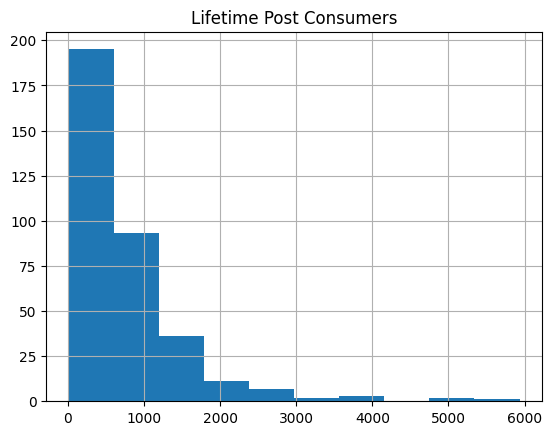

In [32]:
# Observamos a continuación que hay un claro sesgo positivo en la variable de salida:
ytrain.hist();

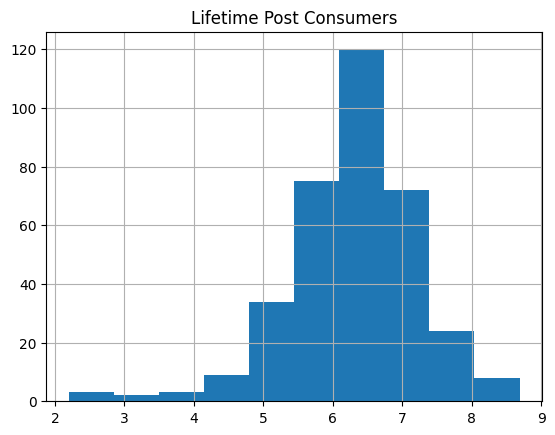

In [33]:
ytrainlog = np.log(ytrain)   # Recordemos que nuestra variable de salida en un problema
ytrainlog.hist();            # de Regresión se recomienda que esté aproximadamente
                             # acampanada, por lo que la ajustaremos con el logaritmo
                             # natural como primera aproximación.

In [34]:
# Para una primera aproximación, podemos decir que se ajusta de manera aceptable
# la distribución con logaritmo a una acampanada.
# Procedemos entonces de la misma manera con Val y Test:
yvallog = np.log(yval)
ytestlog = np.log(ytest)

In [35]:
# Aplicaremos lo mínimo de transformaciones.
# Las nuevas variables horas_sin y horas_cos ya están escaladas entre -1 y +1, por
# lo que podemos dejarlas así y solamente cuidar sus posibles datos perdidos.

num_pipe = Pipeline(steps = [('numImp', SimpleImputer(strategy='median')),
                             ('scaler', MinMaxScaler())
                             ])
num_pipe_nombres = [0]   # ['Page total likes']  puedes indicar solamente el índice de la columna.


# Las ordinales las identificamos como tales:
ord_pipe = Pipeline(steps =  [('OrdImp', SimpleImputer(strategy='most_frequent')),
                              ('Ordfun', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1 ))
                              ])
ord_pipe_nombres = [3,4]   # ['Post Month', 'Post Weekday']


# Transformación del factor categórico de entrada "Type":
catMap_pipe = Pipeline(steps = [('catMap', FunctionTransformer(mi_type))])
catMap_pipe_nombres = ['Type']


# Las nominales las transformamos con One-Hot-Encoder:
nom_pipe = Pipeline(steps = [('NomImp', SimpleImputer(strategy='most_frequent')),
                             ('ohe', OneHotEncoder(drop='first',
                                                   handle_unknown='ignore',
                                                   ))])
nom_pipe_nombres = [1,2,5]  # ['Type', 'Category', 'Paid']


# Variables numéricas con la hora:
hora_pipe = Pipeline(steps = [('HoraImp', SimpleImputer(strategy='mean'))])
hora_pipe_nombres = [6,7]   # ['horas_sin', 'horas_cos']


# Conjuntamos las transformaciones que aplicaremos:
columnasTransformer = ColumnTransformer(transformers = [('numpow', num_pipe, num_pipe_nombres),
                                                        ('catOrd', ord_pipe, ord_pipe_nombres),
                                                        ('catNom', nom_pipe, nom_pipe_nombres),
                                                        ('catmap', catMap_pipe, catMap_pipe_nombres),
                                                        ('hora', hora_pipe, hora_pipe_nombres)
                                                        ],
                                        remainder='passthrough')



# Solo para saber la nueva cantidad de columnas después de las trasnformaciones:
XtrainT = columnasTransformer.fit_transform(Xtrain)  # Ajustamos con Train...
print('Variables de entrada original:', Xtrain.shape)
print('Variables de entrada transformadas:', XtrainT.shape)

Variables de entrada original: (350, 8)
Variables de entrada transformadas: (350, 12)


### **Criterio para determinar si un modelo está subentrenado en un problema de Regresión:**

In [36]:
# Existen varios criterios para determinar si un modelo de regresión está
# subentrenado, veamos a continuación unos de ellos.

# El valor de RMSE-Root-Mean-Square-Error, se utiliza para medir el desempeño
# mínimo que debiera obtener un modelo de regresión, es decir, este valor
# se toma usualmente como el valor del modelo subentrenado y se compara generalmente
# con el valor de la desviación estándar de la variable de salida, ya sea que la
# estés tomando de manera original o con los datos transformados.
# Veamos el valor de ambas:

print('Desv-Est y-original: %.3f' % ytrain.values.std(ddof=1))        # Usemos la desviación estándar muestral
print('Desv-Est y-logaritmo: %.3f' % ytrainlog.values.std(ddof=1))    # ajustando los grados de libertad.

Desv-Est y-original: 770.963
Desv-Est y-logaritmo: 0.916


#### **Recordemos que la desviación estándar está en las mismas unidades de la variable original, por lo que en este caso tendríamos que la desviación estándar nos habla de aproximadamente 771 personas que dieron click en alguna parte del post.**

#### **En esta activiad estaremos comparando los errores en términos del logaritmo de la variable de salida, por lo que nuestro valor de referencia será el valor que obtienes en Desv_Est y_logaritmo=0.916 (aproximadamente). Así, los errores RMSE de los valores de predicción y los reales de los modelos que estarás obteniendo, deberán ser menores a este valor para no considerarlos subentrenados.**

#### **NOTA sobre los grados de libertad ddof (delta degree of freedom):**

Ver documentación: https://numpy.org/doc/stable/reference/generated/numpy.std.html

#### **Estricamente, desde el punto de vista matemático las desviaciones estándar que uno calcula deben ser las muestrales, es decir, std(ddof=1). Sin embargo, en la práctica es muy común usar la función con su valor predeterminado que es ddof=0 y que se traduce a calcular la desviación estándar poblacional. Repito, en la práctica suele pasarse por alto este ajuste porque cuando se tienen datos de miles o más regitros, la diferencia entre el resultado problacional y el muestral es mínima. En esta actividad lo pongo solamente para recordarlo y en dado caso cuando tengas menos de 100 registros sí hacer este ajuste, porque la diferencia entre ambos ya podría ser importante.**

In [37]:
# Como se va a utilizar Validación-Cruzada, concatenamos los conjuntos de entrenamiento y validación
# en uno nuevo conjunto aumentado que llamaremos trainval para utilizar como entrenamiento:

Xtrainval = pd.concat([Xtrain, Xval], axis=0)
ytrainvallog = pd.concat([ytrainlog, yvallog], axis=0)

## **Ejercicio 4**


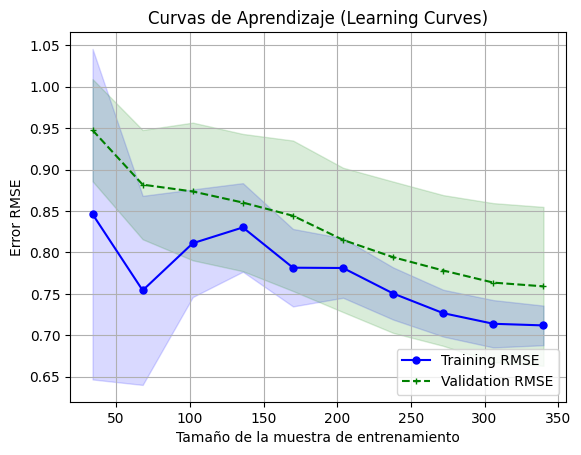

In [38]:
# Ejercicio 4a.

# Al ejecutar las siguientes líneas de código determina si el modelo de
# Bosque Aleatorio con sus valores de hiperparámetros predeterminadas está
# Subentrenado o Sobreentrenado. De ser así, busca los valores de sus
# hiperparámetros que consideres más adecuados para que ya no
# esté sub-o-sobreentrenado:


# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

elmodelo_RF = RandomForestRegressor(
    n_estimators=4000,  # Más árboles para suavizar el modelo
    max_depth=25,
    min_samples_split=30,
    min_samples_leaf=10,
    max_features='log2',
    random_state=1
)

# +++++++++++++ Tesrmina sección de agregar código +++++++++++++++++++++



mipipe = Pipeline(steps=[('ct',columnasTransformer),('m', elmodelo_RF)])

train_sizes, train_scores, val_scores = learning_curve(estimator=mipipe,
                                                        X=Xtrainval,
                                                        y=np.ravel(ytrainvallog),
                                                        cv=5,
                                                        train_sizes= np.linspace(0.1, 1.0, 10),
                                                        scoring= 'neg_mean_squared_error',  # error MSE
                                                        n_jobs=-1)



# Calculamos los promedios y desviación estándar de entrenamiento para RMSE,
# como tenemos los de MSE, debemos obtener su raíz cuadrada. El negativo es porque
# sklearn nos devuelve en realidad el negativo del Error Cuadrático Medio MSE:

rmse_train_scores = np.sqrt(-train_scores)
rmse_val_scores = np.sqrt(-val_scores)

train_mean = np.mean(rmse_train_scores, axis=1)
train_std = np.std(rmse_train_scores, axis=1, ddof=1)   # aquí también hacemos el ajuste de la desviación estándar muestral.
val_mean = np.mean(rmse_val_scores, axis=1)
val_std = np.std(rmse_val_scores, axis=1, ddof=1)


plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')

plt.title('Curvas de Aprendizaje (Learning Curves)')
plt.xlabel('Tamaño de la muestra de entrenamiento')
plt.ylabel('Error RMSE')
plt.grid()
plt.legend(loc='lower right')
plt.show()


In [39]:
# Ejercicio 4b.

# Una vez que verifiques que no está sobreentrenado o subentrenado el modelo,
# podemos calcular el RMSE del mejor ajuste con los datos de Prueba.
# Incluye los valores de tus mejores hiperparámetros encontrados del RandomForest:

# ++++++++++++++ Incluye aquí tus ajustes ++++++++++++++++++++++++++++++


elmodelo_RF = RandomForestRegressor(
    n_estimators=4000,
    max_depth=25,
    min_samples_split=30,
    min_samples_leaf=10,
    max_features='log2',
    random_state=1
)



# +++++++++++++ Tesrmina sección de realizar ajustes +++++++++++++++++++++


mipipe = Pipeline(steps=[('ct',columnasTransformer),('m', elmodelo_RF)])
mipipe.fit(pd.DataFrame(Xtrainval, columns=Xtrain.columns), np.ravel(ytrainvallog))
yhattest_RF = mipipe.predict(Xtest)

print('Error RSME(Test) de Random Forest: %.3f' % np.sqrt(mean_squared_error(np.ravel(ytestlog), yhattest_RF)))

Error RSME(Test) de Random Forest: 0.719


## **Ejercicio 5**

### **Repite el mismo proceso del Ejercicio 4 anterior para obtener los hiperparámetros que nos lleven a casos de modelos no subentrenados o sobreentrenados, en cada uno de los siguientes casos:**

*   **a. Extreme Gradient Boost XGBoost**
*   **b. Máquina de Vector Soporte SVM**
*   **c. Red Neuronal Perceptrón Multicapa MLP**

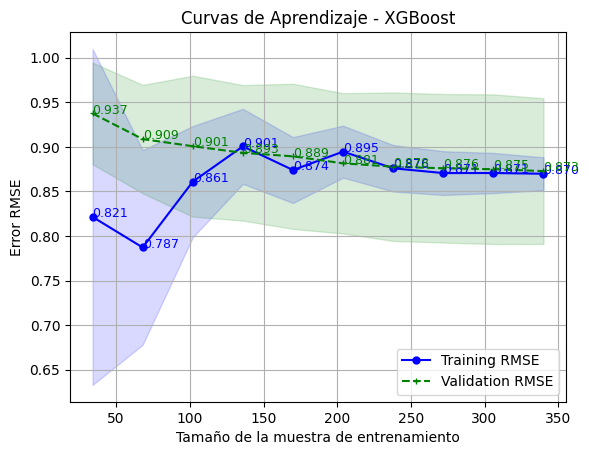

Error RMSE (Test) de XGBoost: 0.792


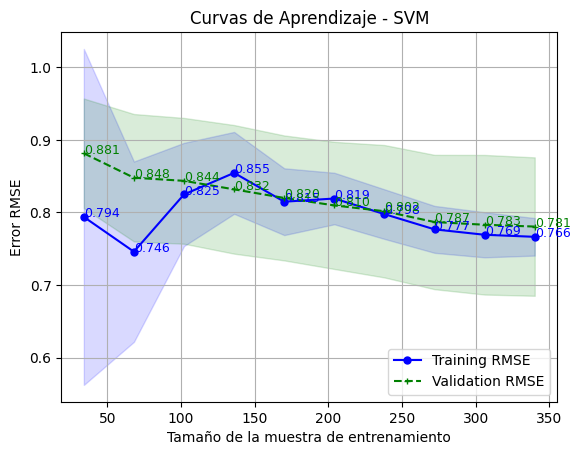

Error RMSE (Test) de SVM: 0.717


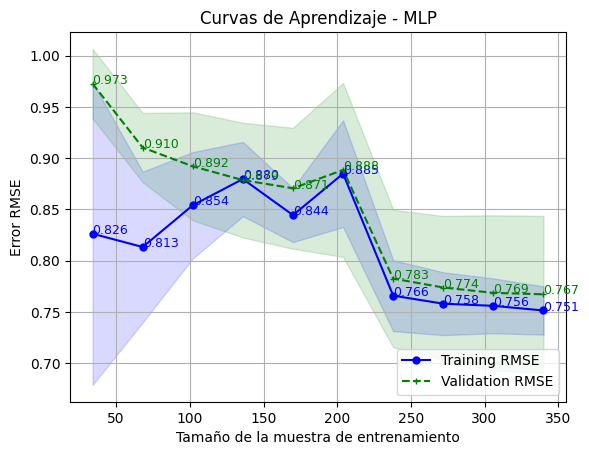

Error RMSE (Test) de MLP: 0.752


In [40]:
# Incluye a continuación las celdas y líneas de código que consideres necesarias
# para responder el Ejercicio 5a, 5b y 5c.
#Ejercicio 5a XGB
elmodelo_XGB = XGBRegressor(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.005,
    subsample=0.5,
    colsample_bytree=0.5,
    gamma=0.5,
    reg_lambda=3.0,
    reg_alpha=0.5,
    random_state=1
)


# pipeline
mipipe_XGB = Pipeline(steps=[('ct', columnasTransformer), ('m', elmodelo_XGB)])

# Generar curvas de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    estimator=mipipe_XGB,
    X=Xtrainval,
    y=np.ravel(ytrainvallog),
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Calcular RMSE
rmse_train_scores = np.sqrt(-train_scores)
rmse_val_scores = np.sqrt(-val_scores)

train_mean = np.mean(rmse_train_scores, axis=1)
train_std = np.std(rmse_train_scores, axis=1, ddof=1)
val_mean = np.mean(rmse_val_scores, axis=1)
val_std = np.std(rmse_val_scores, axis=1, ddof=1)

# Graficar curvas de aprendizaje con valores en los puntos
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')

# Añadir etiquetas con los valores de RMSE
for i, (train_val, val_val) in enumerate(zip(train_mean, val_mean)):
    plt.text(train_sizes[i], train_val, f'{train_val:.3f}', fontsize=9, color='blue')
    plt.text(train_sizes[i], val_val, f'{val_val:.3f}', fontsize=9, color='green')

plt.title('Curvas de Aprendizaje - XGBoost')
plt.xlabel('Tamaño de la muestra de entrenamiento')
plt.ylabel('Error RMSE')
plt.grid()
plt.legend(loc='lower right')
plt.show()

# Entrenar el modelo con los datos de entrenamiento
mipipe_XGB.fit(pd.DataFrame(Xtrainval, columns=Xtrain.columns), np.ravel(ytrainvallog))

# Predecir en los datos de prueba
yhattest_XGB = mipipe_XGB.predict(Xtest)

# Calcular RMSE
rmse_test_XGB = np.sqrt(mean_squared_error(np.ravel(ytestlog), yhattest_XGB))
print('Error RMSE (Test) de XGBoost: %.3f' % rmse_test_XGB)

#Ejercicio 5b XGB
elmodelo_SVM = SVR(
    kernel='rbf',
    C=0.5,
    epsilon=0.2,
    gamma='scale',
    tol=1e-3,
    max_iter=-1
)

# Crear el pipeline
mipipe_SVM = Pipeline(steps=[('ct', columnasTransformer), ('m', elmodelo_SVM)])

# Generar curvas de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    estimator=mipipe_SVM,
    X=Xtrainval,
    y=np.ravel(ytrainvallog),
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Calcular RMSE
rmse_train_scores = np.sqrt(-train_scores)
rmse_val_scores = np.sqrt(-val_scores)

train_mean = np.mean(rmse_train_scores, axis=1)
train_std = np.std(rmse_train_scores, axis=1, ddof=1)
val_mean = np.mean(rmse_val_scores, axis=1)
val_std = np.std(rmse_val_scores, axis=1, ddof=1)

# Graficar curvas de aprendizaje con valores en los puntos
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')

# Añadir etiquetas con los valores de RMSE
for i, (train_val, val_val) in enumerate(zip(train_mean, val_mean)):
    plt.text(train_sizes[i], train_val, f'{train_val:.3f}', fontsize=9, color='blue')
    plt.text(train_sizes[i], val_val, f'{val_val:.3f}', fontsize=9, color='green')

plt.title('Curvas de Aprendizaje - SVM')
plt.xlabel('Tamaño de la muestra de entrenamiento')
plt.ylabel('Error RMSE')
plt.grid()
plt.legend(loc='lower right')
plt.show()

# Entrenar el modelo con los datos de entrenamiento
mipipe_SVM.fit(pd.DataFrame(Xtrainval, columns=Xtrain.columns), np.ravel(ytrainvallog))

# Predecir en los datos de prueba
yhattest_SVM = mipipe_SVM.predict(Xtest)

# Calcular RMSE
rmse_test_SVM = np.sqrt(mean_squared_error(np.ravel(ytestlog), yhattest_SVM))
print('Error RMSE (Test) de SVM: %.3f' % rmse_test_SVM)
#Ejercicio 5c MLP
elmodelo_MLP = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='logistic',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.0005,
    max_iter=1000,
    random_state=1
)

# Crear el pipeline
mipipe_MLP = Pipeline(steps=[('ct', columnasTransformer), ('m', elmodelo_MLP)])

# Generar curvas de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    estimator=mipipe_MLP,
    X=Xtrainval,
    y=np.ravel(ytrainvallog),
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Calcular RMSE
rmse_train_scores = np.sqrt(-train_scores)
rmse_val_scores = np.sqrt(-val_scores)

train_mean = np.mean(rmse_train_scores, axis=1)
train_std = np.std(rmse_train_scores, axis=1, ddof=1)
val_mean = np.mean(rmse_val_scores, axis=1)
val_std = np.std(rmse_val_scores, axis=1, ddof=1)

# Graficar curvas de aprendizaje con valores en los puntos
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')

# Añadir etiquetas con los valores de RMSE
for i, (train_val, val_val) in enumerate(zip(train_mean, val_mean)):
    plt.text(train_sizes[i], train_val, f'{train_val:.3f}', fontsize=9, color='blue')
    plt.text(train_sizes[i], val_val, f'{val_val:.3f}', fontsize=9, color='green')

plt.title('Curvas de Aprendizaje - MLP')
plt.xlabel('Tamaño de la muestra de entrenamiento')
plt.ylabel('Error RMSE')
plt.grid()
plt.legend(loc='lower right')
plt.show()

# Entrenar el modelo con los datos de entrenamiento
mipipe_MLP.fit(pd.DataFrame(Xtrainval, columns=Xtrain.columns), np.ravel(ytrainvallog))

# Predecir en los datos de prueba
yhattest_MLP = mipipe_MLP.predict(Xtest)

# Calcular RMSE
rmse_test_MLP = np.sqrt(mean_squared_error(np.ravel(ytestlog), yhattest_MLP))
print('Error RMSE (Test) de MLP: %.3f' % rmse_test_MLP)

## **Ejercicio 6**

### **Importancia de características**

#### **Ejercicio 6a.**

*   **Con base al mejor modelo encontrado, realiza una análisis de importancia de características con el conjunto de prueba (Test).**

*   **Obtener un diagrama de cajas o algún tipo de visualización para mostrar estos resultados.**


#### **Ejercicio 6b.**

*   **Con base a los gráficos obtenidos indica cuáles son los tres factores más importantes y que dan mayor información para la predicción de la variable de salida.**

*  **Compara tus resultados con el resultado de la Figura 6 del artículo de ELSEVIER. Indica tus coincidencias y diferencias.**

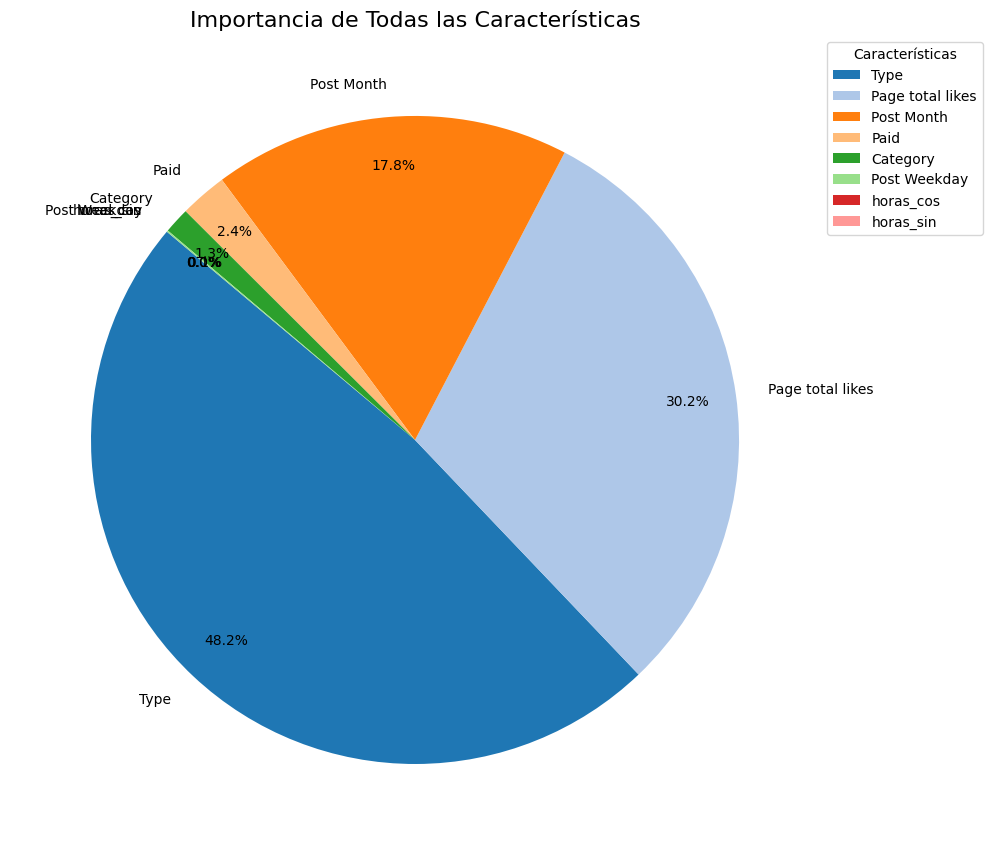

            Feature  Importance
1              Type    0.190256
0  Page total likes    0.119299
3        Post Month    0.070229
5              Paid    0.009312
2          Category    0.005087
4      Post Weekday    0.000293
7         horas_cos    0.000000
6         horas_sin    0.000000


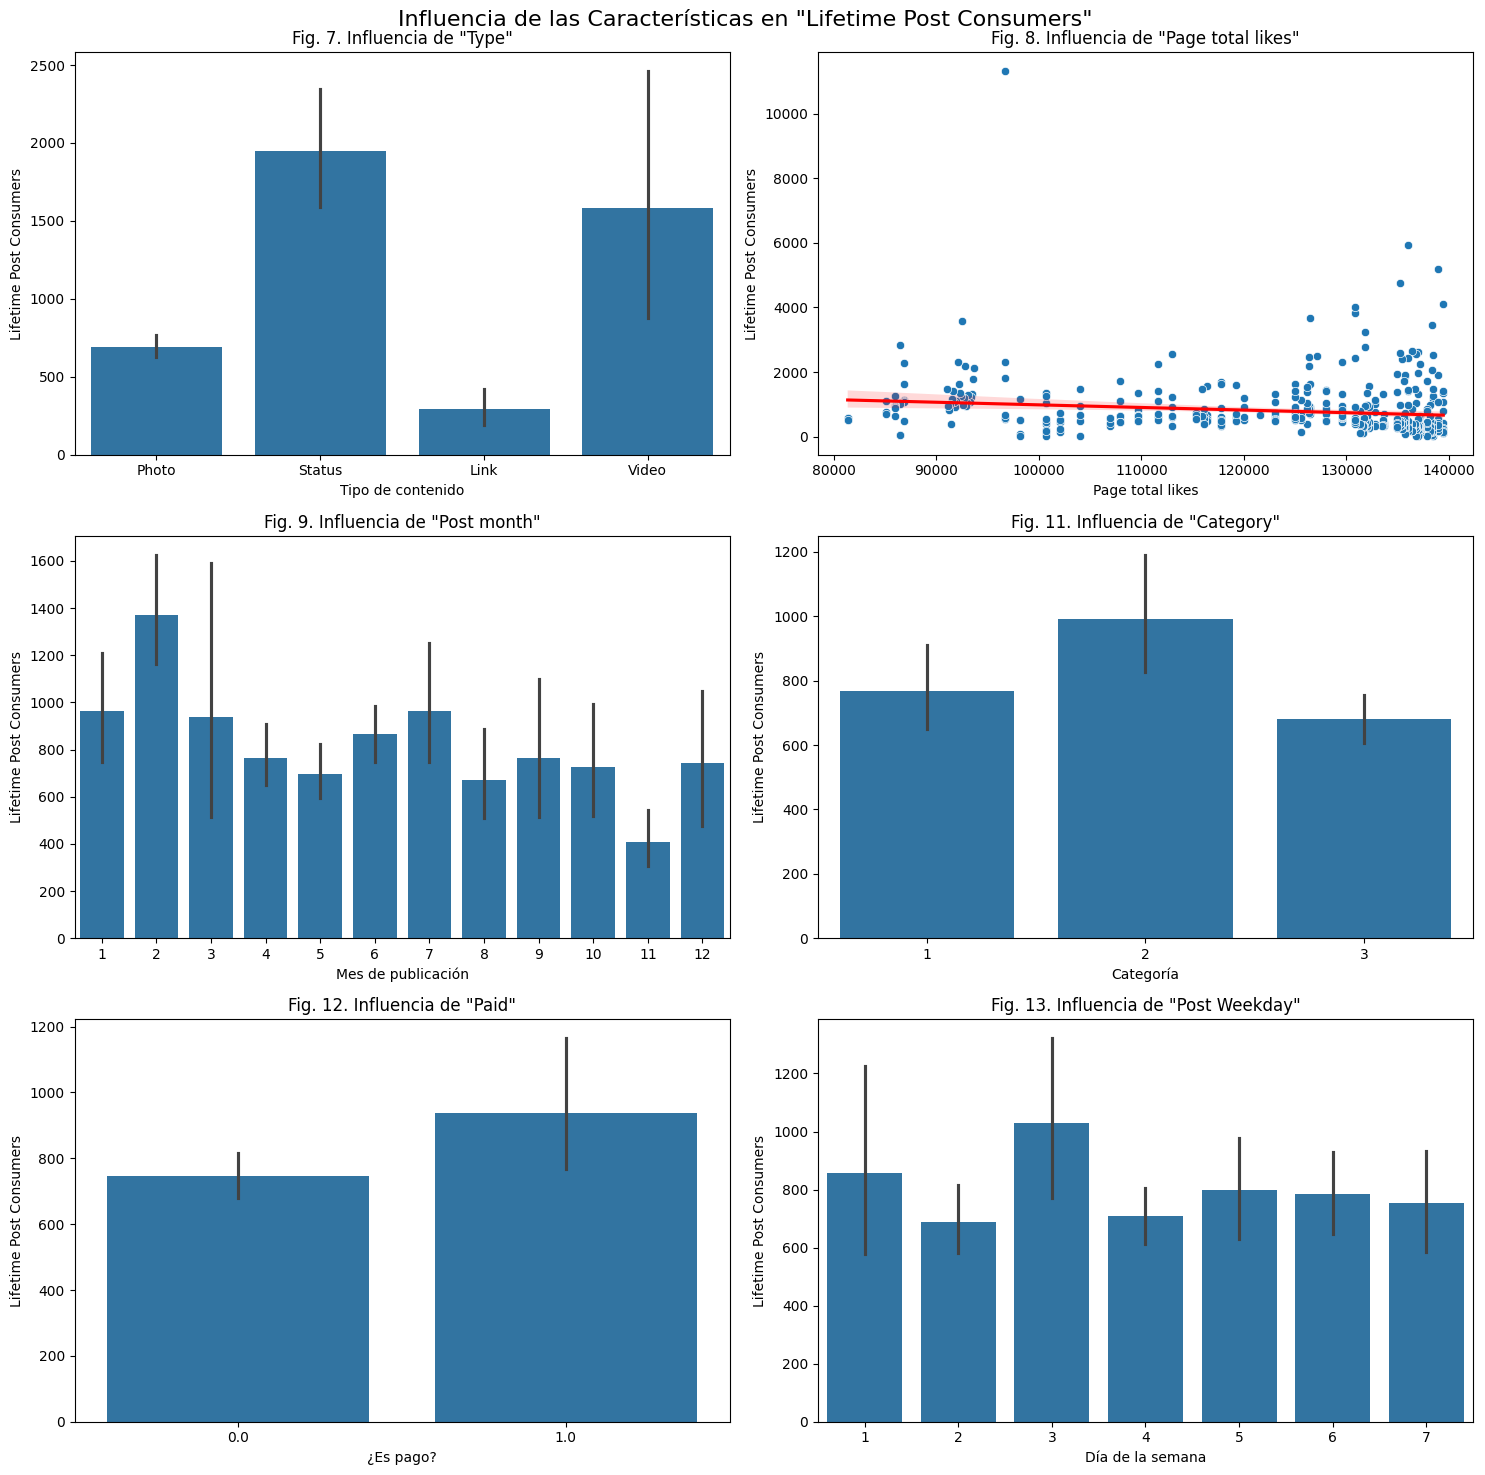

In [41]:
#Modelo seleccionado RF
#Multiple comparaciones
# Calcular la importancia de las características usando permutation importance
result = permutation_importance(
    mipipe, Xtest, np.ravel(ytestlog), n_repeats=10, random_state=1, n_jobs=-1
)

# Obtener la importancia de las características
importances = result.importances_mean
feature_names = Xtrain.columns  # Nombres de las características

# Crear un DataFrame para facilitar el manejo de los datos
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar las características por importancia (de mayor a menor)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Asegurarse de que las importancias sean no negativas
importance_df['Importance'] = importance_df['Importance'].clip(lower=0)

# Crear el gráfico de pastel con todas las variables
plt.figure(figsize=(10, 10))

# Usar un colormap para asignar colores únicos a cada característica
colors = plt.cm.tab20.colors

# Crear el gráfico de pastel
wedges, texts, autotexts = plt.pie(
    importance_df['Importance'],
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85
)

# Añadir una leyenda fuera del gráfico
plt.legend(
    wedges,
    importance_df['Feature'],
    title="Características",
    loc="upper left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Ajustar el layout para que la leyenda no se superponga con el gráfico
plt.tight_layout()

# Mostrar el gráfico
plt.title('Importancia de Todas las Características', fontsize=16)
plt.show()

# Mostrar la tabla con todas las características y su importancia
print(importance_df)

# +++++++++++++ Gráficas adicionales +++++++++++++++++++++

# Reemplazar valores nulos en Paid
data['Paid'] = data['Paid'].fillna(0)

# Crear una figura con subplots para las gráficas adicionales
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Influencia de las Características en "Lifetime Post Consumers"', fontsize=16)

# Figura 7: Influencia de "Type"
sns.barplot(x='Type', y='Lifetime Post Consumers', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Fig. 7. Influencia de "Type"')
axes[0, 0].set_xlabel('Tipo de contenido')
axes[0, 0].set_ylabel('Lifetime Post Consumers')

# Figura 8: Influencia de "Page total likes"
sns.scatterplot(x='Page total likes', y='Lifetime Post Consumers', data=data, ax=axes[0, 1])
sns.regplot(x='Page total likes', y='Lifetime Post Consumers', data=data, ax=axes[0, 1], scatter=False, color='red')
axes[0, 1].set_title('Fig. 8. Influencia de "Page total likes"')
axes[0, 1].set_xlabel('Page total likes')
axes[0, 1].set_ylabel('Lifetime Post Consumers')

# Figura 9: Influencia de "Post month"
sns.barplot(x='Post Month', y='Lifetime Post Consumers', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Fig. 9. Influencia de "Post month"')
axes[1, 0].set_xlabel('Mes de publicación')
axes[1, 0].set_ylabel('Lifetime Post Consumers')

# Figura 11: Influencia de "Category"
sns.barplot(x='Category', y='Lifetime Post Consumers', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Fig. 11. Influencia de "Category"')
axes[1, 1].set_xlabel('Categoría')
axes[1, 1].set_ylabel('Lifetime Post Consumers')

# Figura 12: Influencia de "Paid"
sns.barplot(x='Paid', y='Lifetime Post Consumers', data=data, ax=axes[2, 0])
axes[2, 0].set_title('Fig. 12. Influencia de "Paid"')
axes[2, 0].set_xlabel('¿Es pago?')
axes[2, 0].set_ylabel('Lifetime Post Consumers')

# Figura 13: Influencia de "Post Weekday"
data['Post Weekday'] = data['Post Weekday'].fillna(0)
sns.barplot(x='Post Weekday', y='Lifetime Post Consumers', data=data, ax=axes[2, 1])
axes[2, 1].set_title('Fig. 13. Influencia de "Post Weekday"')
axes[2, 1].set_xlabel('Día de la semana')
axes[2, 1].set_ylabel('Lifetime Post Consumers')

# Ajustar el layout
plt.tight_layout()
plt.show()


### ++++++++ Inicia la sección de agregar texto: +++++++++++
### **Ejercicio 6b**

En este ejercicio, se analizan los resultados obtenidos a partir de los gráficos generados, comparándolos con los hallazgos presentados en el artículo de ELSEVIER. A continuación, se desglosan los puntos clave:

#### **1. Factores más importantes**
- **Resultados del modelo:**
  1. **Type**: 48.2%
  2. **Page total likes**: 30.2%
  3. **Post month**: 17.8%

- **Resultados del artículo de ELSEVIER:**
  1. **Type**: 36%
  2. **Page total likes**: 17%
  3. **Post month**: 15%

**Observaciones:**
- El orden de importancia de los factores coincide entre el modelo y el artículo, lo que indica que el modelo fue capaz de identificar correctamente las variables más relevantes.
- Sin embargo, los porcentajes de importancia difieren significativamente. Esto sugiere que, aunque el modelo captura la jerarquía de importancia, la escala y el sesgo en la distribución de importancia no son idénticos a los del estudio.
- El modelo parece subestimar la importancia de otras variables como **Category**, **Paid**, **Hours** y **Weekday**, las cuales tienen un impacto menor en comparación con el artículo.

#### **2. Análisis de las visualizaciones**
- **Figura 7 (Type):**
  - El modelo identifica que **Status** tiene el mayor efecto dentro de la categoría **Type**, lo cual coincide con el artículo.
  - Sin embargo, la escala de impacto difiere, lo que podría indicar una diferencia en la magnitud del efecto.

- **Figura 8 (Page total likes):**
  - Se observa una tendencia negativa en relación con el número de likes de la página, lo cual coincide con el estudio.
  - No obstante, la línea de tendencia en el modelo es menos pronunciada que en el artículo, lo que sugiere que el modelo es más conservador en este aspecto.
  - Esto podría reflejar cambios en el comportamiento de los usuarios en Facebook con el tiempo, ya que la red social ha evolucionado desde la publicación del artículo.

- **Figura 9 (Post month):**
  - El modelo acierta en identificar a **Febrero** como un mes con un impacto positivo, lo cual coincide con el artículo.
  - Sin embargo, no logra capturar correctamente los meses de **Junio** y **Julio**, que en el artículo son los más destacados.
  - A pesar de esto, la diferencia entre los meses no es muy amplia, lo que indica que el modelo mantiene un rango de variación aceptable.

#### **3. Otras visualizaciones**
- **Post Hour:**
  - No se pudo generar el gráfico debido a dificultades en el tratamiento y significancia de las variables relacionadas con la hora (seno y coseno).
  - Esto sugiere que el modelo no pudo capturar adecuadamente la influencia de la hora en la que se publica el contenido.

- **Figura 11 (Category):**
  - El modelo difiere con el artículo al identificar **Inspiración** como la categoría más importante, en lugar de **Acción**.
  - Sin embargo, la escala de impacto es similar, con valores entre 700 y 900, lo que indica que, aunque la categoría más importante no coincide, la magnitud del impacto es comparable.

- **Figura 12 (Paid):**
  - El modelo identifica correctamente que la publicidad pagada tiene un impacto mayor en la cantidad de clics, lo cual coincide con el artículo.
  - La diferencia en el impacto entre publicidad pagada y no pagada es similar a la reportada en el estudio.

- **Post Weekday:**
  - El modelo no identifica a **Lunes** y **Viernes** como los días con mejores resultados, sino a **Martes**.
  - A pesar de esta discrepancia, la escala y las diferencias entre los días no están muy alejadas de los resultados del artículo.

### ++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio 7**

### **Incluye tus conclusiones finales de la Actividad.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++


Esta actividad ha sido una de las más desafiantes en términos computacionales, pero también una de las más enriquecedoras en cuanto a aprendizaje. A diferencia de los modelos de categorización que habíamos trabajado anteriormente, este ejercicio se centró en predecir un aspecto numérico, lo cual amplió mi comprensión sobre las diferentes aplicaciones del aprendizaje automático.

Uno de los aspectos más interesantes fue el uso de curvas de aprendizaje, las cuales resultaron ser una herramienta invaluable para evaluar el rendimiento del modelo. Estas curvas permitieron identificar si el modelo estaba sufriendo de sobreajuste (overfitting) o subajuste (underfitting), lo cual fue crucial para ajustar los hiperparámetros y mejorar la capacidad de generalización del modelo. A través de estas curvas, pude observar cómo el modelo mejoraba con más datos y cómo ciertos ajustes en los hiperparámetros impactaban en su desempeño. Sin embargo, este proceso también fue uno de los más laboriosos, ya que encontrar la combinación óptima de hiperparámetros requiere de paciencia y experimentación. Aunque los resultados obtenidos están dentro de un umbral aceptable, siempre existe margen para mejorar.

En cuanto a los resultados, el modelo demostró ser capaz de identificar correctamente las variables más importantes (Type, Page total likes, Post month), aunque con diferencias en los porcentajes de importancia en comparación con el artículo de referencia. Esto sugiere que, si bien el modelo captura la jerarquía de las variables clave, la escala de impacto no es idéntica. Además, se observaron algunas discrepancias en la identificación de ciertos meses y días de la semana, lo cual indica que el modelo podría refinarse para capturar mejor estos patrones temporales.

Un punto que destacar es la dificultad en el tratamiento de variables como Post Hour, donde el modelo no pudo capturar adecuadamente la influencia de la hora de publicación. Esto resalta la importancia de un preprocesamiento más robusto y la necesidad de explorar técnicas adicionales para manejar variables temporales de manera más efectiva.

En términos generales, el modelo es consistente en identificar las variables clave, pero con un ajuste más fino de los hiperparámetros y un enfoque más detallado en el preprocesamiento de datos, se podría mejorar la precisión en la cuantificación del impacto de cada factor.

Finalmente, esta actividad no solo amplió mis conocimientos en el ámbito del aprendizaje automático, sino que también me permitió mejorar mis habilidades en la creación de visualizaciones y en la interpretación de resultados. Aunque Random Forest fue el modelo que mejor se ajustó a los datos, esta experiencia me dejó con la certeza de que siempre hay margen para mejorar, ya sea en la selección de algoritmos, en la optimización de hiperparámetros o en la interpretación de los resultados. Sin duda, fue una actividad que combinó desafíos técnicos con un gran potencial de aprendizaje.


### ++++++++ Termina la sección de agregar texto. +++++++++++

>> **Fin de la Actividad de la Semana 7**